# Auswertung der DLA Daten Bestand Ilse Aichinger (BF00019971)

In [2]:
#!/usr/bin/env python3
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from collections import Counter
import json, re

with open("BF00019971.json", "r", encoding="utf-8") as fh:
    records = json.load(fh)
print( len(records), "Einträge" )
#records[2]

2020 Einträge


Der Bestand **A:Aichinger, Ilse** hat die Mediennummer **BF000199715**.

Für den Bezug des Datenbestands über dataservice muss die letzte Ziffer (Prüfnummer) entfernt werden: 

*collection_id_mv:**BF00019971***

## JSON-Felder

In [3]:
counter = Counter()
types = {}

for record in records:
    counter.update(record.keys())

    for key, value in record.items():
        if key not in types:
            types[key] = type(value).__name__

print(f"{'Feld':35} {'Typ':10} {'Anzahl':>8}")
print("-" * 58)

for field, count in sorted(counter.items(), key=lambda x: (-x[1], x[0])):
    print(f"{field:35} {types[field]:10} {count:8}")

Feld                                Typ          Anzahl
----------------------------------------------------------
accessionNumber                     str            2020
category                            str            2020
categorySub                         str            2020
collection_display_mv               list           2020
collection_id_mv                    list           2020
dateCataloged                       str            2020
dateModified                        str            2020
display                             str            2020
displayAddition2                    str            2020
displayName                         str            2020
filterAuthorityRelation_mv          list           2020
filterAuthorityRole_mv              list           2020
filterAuthority_mv                  list           2020
filterCollection_mv                 list           2020
filterFormContent_mv                list           2020
filterLanguageType_mv               list     

# zu den einzelnen Feldern

## accessionNumber

Zugangsnummern im DLA Marbach
* ab dem Jahr 1941 wurden Jahreszahlen in der Zugangsnummer verwendet
* ab dem Jahr 1999 wurde im Rahmen der Umstellung auf Datenbankbetrieb HS am Anfang eingesetzt

#### 1. most_common()

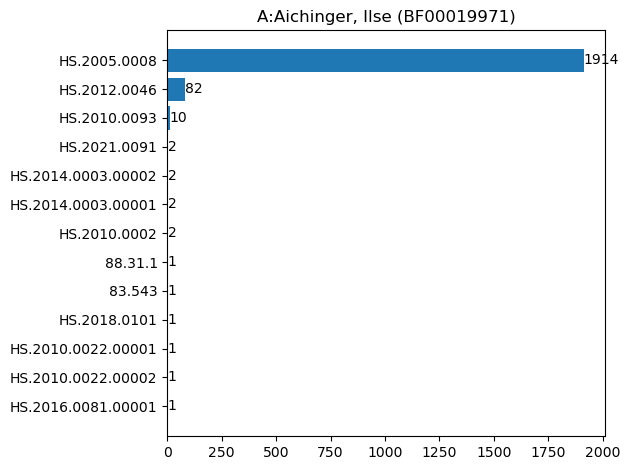

In [8]:
labels, values = zip(*Counter(r["accessionNumber"] for r in records if "accessionNumber" in r).most_common())
bars = plt.barh(labels, values)
plt.gca().invert_yaxis()
plt.bar_label(bars, fmt="%d")
plt.title("A:Aichinger, Ilse (BF00019971)")
plt.tight_layout()
plt.show()

#### 2. alle (/gruppiert)

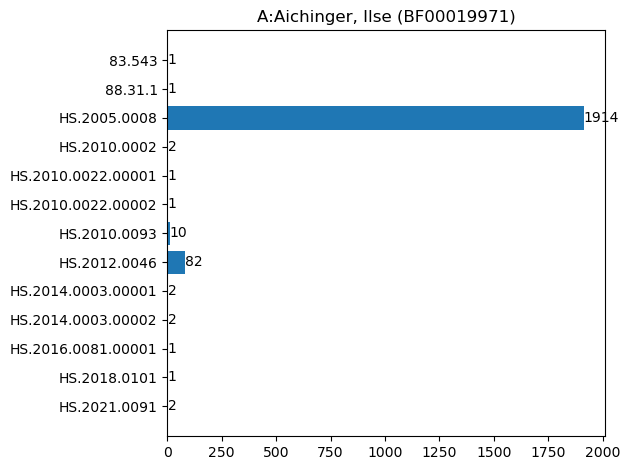

In [13]:
import re
from collections import Counter

def group(a):
    a = a.strip()
    #if m := re.match(r"^(\d{2}\.)", a): return m.group(1)
    #if m := re.match(r"^HS\.(\d{4}\.)", a): return f"HS.{m.group(1)}"
    if m := re.match(r"(.*)", a): return m.group(1)
    return a

counter = Counter(
    group(a)
    for r in records
    for a in r.get("accessionNumber", "").split(";")
    if a.strip()
)

labels = sorted(counter)
values = [counter[x] for x in labels]

bars = plt.barh(labels, values)
plt.gca().invert_yaxis()
plt.bar_label(bars, fmt="%d")
plt.title("A:Aichinger, Ilse (BF00019971)")
plt.tight_layout()
plt.show()

## category

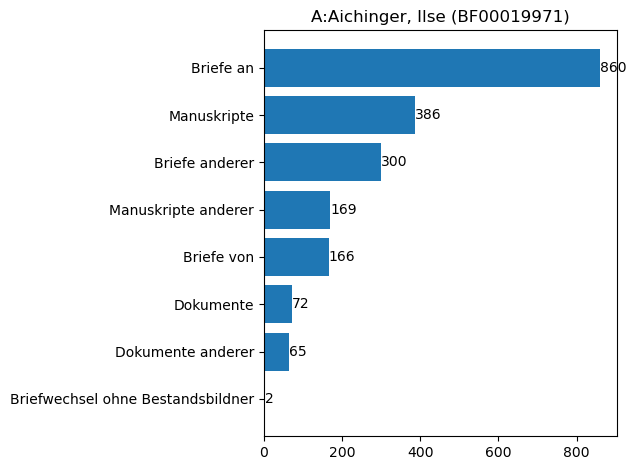

In [14]:
labels, values = zip(*Counter(r["category"] for r in records if "category" in r).most_common())
bars = plt.barh(labels, values)
plt.gca().invert_yaxis()
plt.bar_label(bars, fmt="%d")
plt.title("A:Aichinger, Ilse (BF00019971)")
plt.tight_layout()
plt.show()

## filterLanguageType_mv

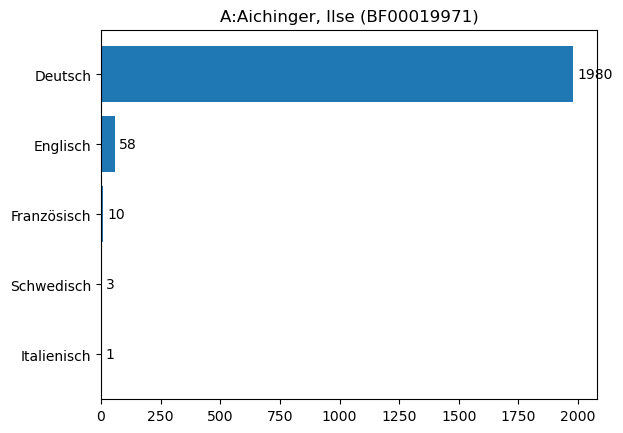

In [15]:
labels, values = zip(*Counter(
    s.replace("␝Original", "")
    for r in records
    for s in r.get("filterLanguageType_mv", [])
).most_common())

bars = plt.barh(labels, values)
plt.gca().invert_yaxis()
plt.bar_label(bars, padding=3)
plt.title("A:Aichinger, Ilse (BF00019971)")
plt.show()

## filterLocationType_mv

In [12]:
counter = Counter()
for record in records:
    counter.update(record.get("filterLocationType_mv", []))
for value, count in counter.most_common():
    print(f"{count:5d}  {value.split('␝', 1)[0]}")

  242  Wien
   64  München
   54  London
   45  Großgmain
   43  Frankfurt am Main
   33  Linz
   26  Lenggries
   25  Salzburg
   24  Hamburg
   19  Stuttgart
   18  Bayerisch Gmain
   16  Berlin
   13  Zürich
   12  Paris
   12  Berlin (West)
   12  Köln
   12  New York, NY
   10  Düsseldorf
    8  Ulm
    8  Geisenhausen
    8  Stockholm
    8  Bremen
    8  Innsbruck
    7  Rom
    7  Bonn
    7  York
    6  Dortmund
    6  Hannover
    6  Graz
    6  Alfermée
    6  Mainz
    5  Florenz
    5  Tübingen
    5  San Francisco, Calif.
    5  Berkeley, Calif.
    5  Rotis
    4  Breitbrunn am Chiemsee
    4  Freiburg im Breisgau
    4  Bern
    4  Ingolstadt
    4  Eutin
    4  Brüssel
    4  Baden-Baden
    4  Woodstock, NY
    4  Sarajevo
    4  Gallneukirchen
    3  Genf
    3  Duisburg
    3  Biarritz
    3  Darmstadt
    3  Sankt Gilgen
    3  Nitra
    3  Dresden
    3  Gmunden
    3  Kilburn
    3  Essen
    3  Karlsruhe
    3  Basel
    3  Heidelberg
    3  Sankt Pölten
    3  

In [13]:
import folium, time, json
from geopy.geocoders import Nominatim

geolocator = Nominatim(user_agent="dla-map")
m = folium.Map(location=[48.2, 16.3], zoom_start=4, tiles="OpenStreetMap")
seen = set()

for record in records:
    for value in record.get("filterLocationType_mv", []):
        place = value.split("␝", 1)[0]

        if place in seen:
            continue
        seen.add(place)

        try:
            location = geolocator.geocode(place)
            if location:
                folium.Marker(
                    [location.latitude, location.longitude],
                    popup=place
                ).add_to(m)
                print(place, location.latitude, location.longitude)

            time.sleep(1) # Nominatim verlangt Pausen zwischen Anfragen

        except Exception as e:
            print(place, e)

m.save("orte_aichinger.html")

Wien 48.2083537 16.3725042
Lichtenberg 48.9212959 7.4812268
Ulm 48.3984968 9.9912458
Venedig 45.4371908 12.3345898
Attersee (Ort) 47.8057725 13.4295429
Geisenhausen 48.4626638 12.2627122
Breitbrunn am Chiemsee 47.8904604 12.400385
Estoril 38.7095707 -9.3901368
Großgmain 47.7252029 12.9075755
Lenggries 47.6831625 11.5763967
Linz 48.3059078 14.286198
Rom 41.8933203 12.4829321
Oslo 59.9133301 10.7389701
Paris 48.8534951 2.3483915
Berlin (West) 38.3326165 -75.361583
Genf 46.2017559 6.1466014
London 51.5074456 -0.1277653
Grado 45.6781065 13.3979091
Dakar 14.693425 -17.447938
Los Angeles, Calif. 34.0536909 -118.242766
Zürich 47.3744489 8.5410422
München 48.1371079 11.5753822
Kampen 52.5559484 5.9033303
Stockholm 59.3251172 18.0710935
Salzburg 47.7981346 13.0464806
Frankfurt am Main 50.1106444 8.6820917
Meiderich 51.4682939 6.7748552
Duisburg 51.434999 6.759562
Stuttgart 48.7784485 9.1800132
Freiburg im Breisgau 47.9960901 7.8494005
Kyoto 35.0115754 135.7681441
Haarlem 52.3837281 4.6435679
Vö

Emden 53.3670541 7.2058304
St. Wolfgang im Salzkammergut 47.749753 13.5026937
Neunkirchen (Saar) 49.34987 7.1841564
Sankt Pölten 48.2043985 15.6229118
Wasserburg a. Inn 48.0615171 12.220026
Liezen 47.5070965 14.2125684
Hochheim am Main 50.0277 8.3587
Wuppertal-Vohwinkel 51.2339487 7.0718314
Bayerisch Gmain 47.7194842 12.8980967
Lübeck 53.866444 10.684738
Itzehoe 53.919448 9.5172441
Bamberg 49.8916044 10.8868478
Luxemburg 49.8158683 6.1296751
San José (Costa Rica) 13.6550233 -88.9905563
Jettingen 47.598553 7.3727619
Söcking 48.0017434 11.3154861
Siegen 48.9573176 8.0427704
Mülhausen 47.7467233 7.3389937
Warmbronn 48.7645631 8.9870213
Dinkelsbühl 49.0691672 10.3194022
Saarlouis 49.3164661 6.749846
Dinslaken 51.5623618 6.7345106
Ferrara 44.7667642 11.827939
Stuttgart-Ost 48.7821428 9.2079413
Überlingen 47.7664456 9.1605106
Mürzzuschlag 47.6053538 15.6723805
Stockdorf 48.0926483 11.4045794
Gelsenkirchen-Buer 51.5611124 7.0607216
Wiesbaden 50.0820384 8.2416556
Zell am Moos 47.9024754 13.318

## dateOriginStart und dateOriginEnd

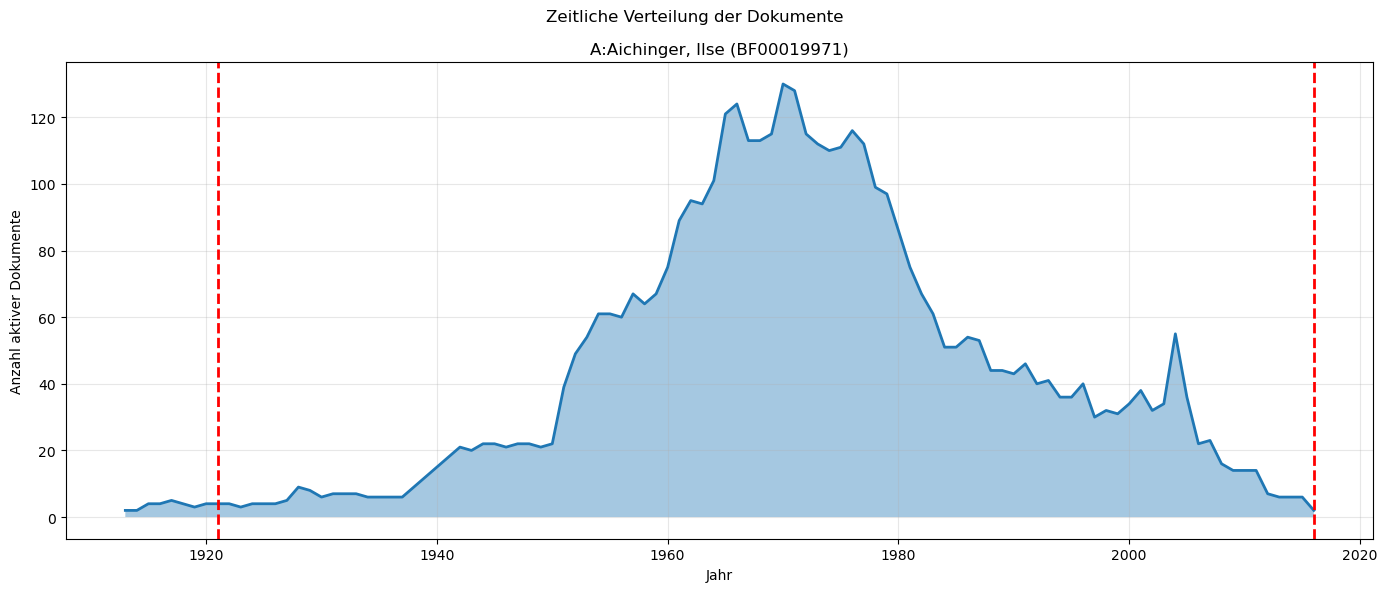

In [16]:
from collections import Counter
import matplotlib.pyplot as plt

counter = Counter()

for record in records:

    start = record.get("dateOriginStart")
    end = record.get("dateOriginEnd")

    if start and start.isdigit():

        start = int(start)

        if end and end.isdigit():
            end = int(end)
        else:
            end = start

        for year in range(start, end + 1):
            counter[year] += 1

years = sorted(counter)
values = [counter[y] for y in years]

plt.figure(figsize=(14,6))
plt.fill_between(years, values, alpha=0.4)
plt.plot(years, values, linewidth=2)

plt.xlabel("Jahr")
plt.ylabel("Anzahl aktiver Dokumente")
plt.title("A:Aichinger, Ilse (BF00019971)")
plt.suptitle("Zeitliche Verteilung der Dokumente")
plt.axvline(x=1921, color='r', linestyle='--', linewidth=2)
plt.axvline(x=2016, color='r', linestyle='--', linewidth=2)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## genre Feld

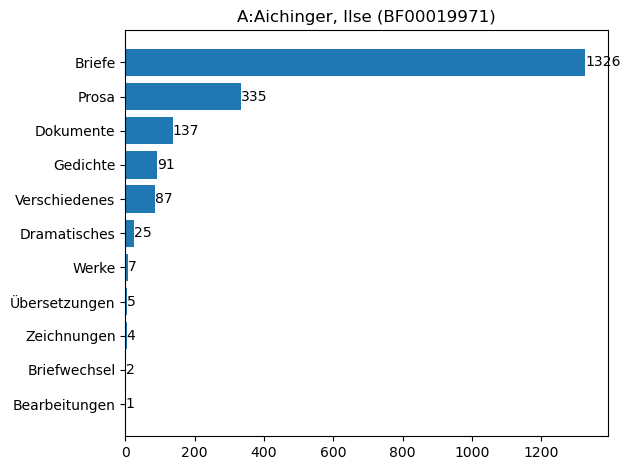

Übersetzungen:
–  Schwebell, Gertrude Clorius: The young lieutenant [Übersetzungen]
–  Chappel, Allen H.: aus Sammlung From: Ilse Aichinger, Kleist, Moos, Fasane (S. Fischer Verlag, 1988) [Übersetzungen]
–  Alldridge, James C.: The Jouet Sisters [Übersetzungen]
–  Alldridge, James C.: Afternoon in Ostend [Übersetzungen]
–  Falkenberg, Betty: Konvolut 3 Gedichte [Übersetzungen]


In [17]:
labels, values = zip(*Counter(r["genre"] for r in records if "genre" in r).most_common())
bars = plt.barh(labels, values)
plt.gca().invert_yaxis()
plt.bar_label(bars, fmt="%d")
plt.title("A:Aichinger, Ilse (BF00019971)")
plt.tight_layout()
plt.show()

print("Übersetzungen:")
for rec in records:
    try:
        if rec["genre"]=="Übersetzungen":
            print('– ', rec["title"])        
    except:
        continue

## filterFormContent_mv

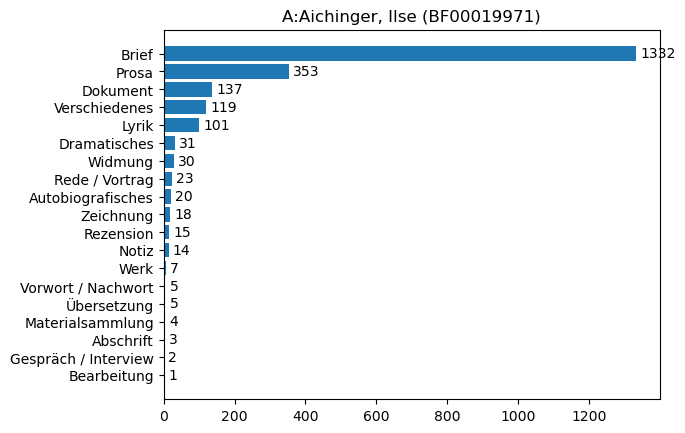

In [18]:
labels, values = zip(*Counter(
    s.replace("␝Original", "")
    for r in records
    for s in r.get("filterFormContent_mv", [])
).most_common())

bars = plt.barh(labels, values)
plt.gca().invert_yaxis()
plt.bar_label(bars, padding=3)
plt.title("A:Aichinger, Ilse (BF00019971)")
plt.show()

## dateCataloged und dateModified

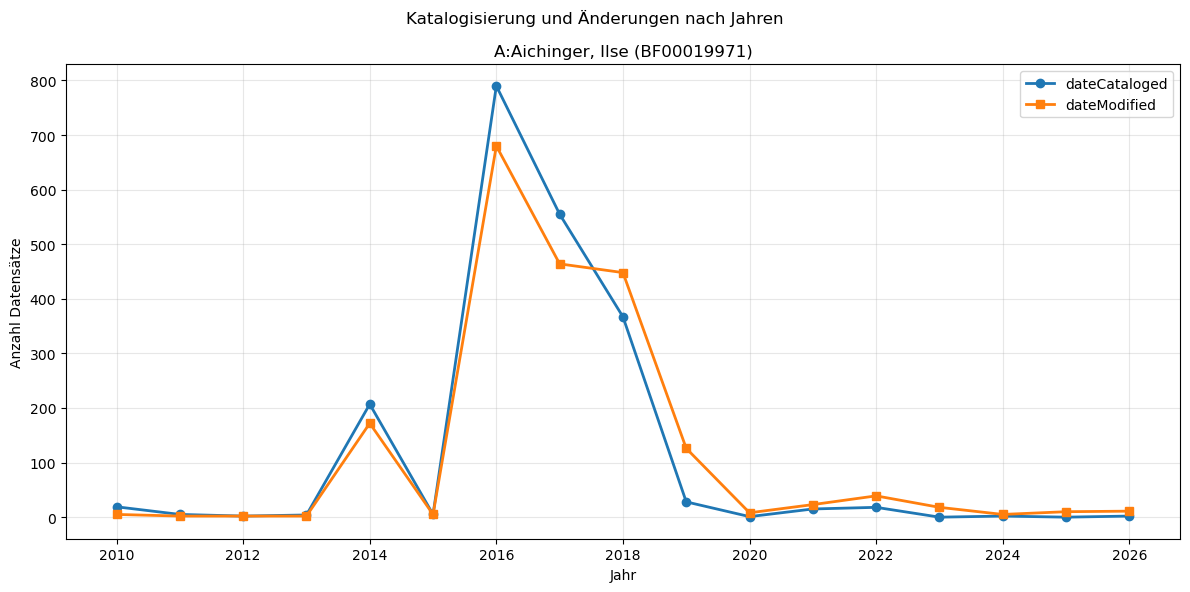

In [19]:
cataloged = Counter()
modified = Counter()

# Jahre zählen
for record in records:
    d = record.get("dateCataloged")
    if d:
        cataloged[int(d[:4])] += 1
    d = record.get("dateModified")
    if d:
        modified[int(d[:4])] += 1

# Gemeinsame Jahresachse
years = sorted(set(cataloged) | set(modified))

cataloged_values = [cataloged[y] for y in years]
modified_values = [modified[y] for y in years]

# Diagramm
plt.figure(figsize=(12, 6))

plt.plot(years, cataloged_values,
         marker="o",
         linewidth=2,
         label="dateCataloged")

plt.plot(years, modified_values,
         marker="s",
         linewidth=2,
         label="dateModified")

plt.xlabel("Jahr")
plt.ylabel("Anzahl Datensätze")
plt.title("A:Aichinger, Ilse (BF00019971)")
plt.suptitle("Katalogisierung und Änderungen nach Jahren")

plt.xticks()
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

## display

In [40]:
counter = Counter()

for record in records:
    display = record.get("display")
    if display:
        counter[display] += 1

for display, count in counter.most_common():
    print(f"{count:5d}  {display}")

   52  Aichinger, Ilse an Michie, Helga [Briefe]
   26  Michie, Helga an Aichinger, Ilse [Briefe]
   14  Aichinger, Ilse: aus Sammlung Unglaubwürdige Reisen [Prosa]
   11  Unbekannt an Aichinger, Ilse [Briefe]
   10  Kremer, Klara an Aichinger, Ilse [Briefe]
    9  Unbekannt an Aichinger, Berta [Briefe]
    7  Kremer, Klara an Aichinger, Berta [Briefe]
    6  Aichinger, Ilse: aus Sammlung Auckland : Hörspiele [Dramatisches]
    6  Aichinger, Ilse: aus Werke: Taschenbuchausgabe in acht Bänden [Werke]
    5  Aichinger, Ilse an Unbekannt [Briefe]
    5  Schutz, Margaret an Aichinger, Berta [Briefe]
    4  Aichinger, Berta an Aichinger, Ilse [Briefe]
    4  Aichinger, Ilse: Konvolut Schattenspiele [Prosa]
    4  Rix, Ruth an Aichinger, Berta [Briefe]
    3  Aichinger, Ludwig: Beschluss in der Verlassenschaftssache Ludwig Aichinger [Dokumente]
    3  Bender, Hans an Aichinger, Ilse [Briefe]
    3  Aichinger, Ilse: aus Sammlung Kleist, Moos, Fasane [Prosa]
    3  Bayerische Akademie der Schö